# ***RQ1: How do different feature-based models perform while detecting money laundering in traditional data representations?***
---
---

In [1]:
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# print("Project root:", project_root)
# print("src exists:", (project_root / "src").exists())

## **ETHEREUM FRAUD DATASET:**

The dataset contains 9,841 Ethereum wallet addresses, each labeled as either legitimate - 0 or fraudulent - 1 (FLAG). It was sourced from Kaggle and is used for binary classification to predicting whether a given address is involved in fraudulent activity.

Each address is described by around 50 features capturing behavioral patterns on the Ethereum blockchain, grouped into:

- Transaction timing: average time between sent/received transactions
- Transaction counts: number of sent, received, and contract-creation transactions
- Ether values: min, max, and average Ether amounts sent/received
- Address interactions: number of unique addresses interacted with
- ERC20 token activity: token transfer counts, unique token types, timing, and values

The goal is to identify illicit addresses based purely on their on chain transaction behavior, without relying on identity information.

In [2]:
from src.data_loader import _load_raw_ethereum

eth_fraud = _load_raw_ethereum()
eth_fraud

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189.29,261601.88,67,43,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,9839,2178,0xffde23396d57e10abf58bd929bb1e856c7718218,1,0.00,0.00,0.00,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Cleaning Process - Ethereum Fraud:**
---

**Steps:**
1. Drop identifier columns - Unnamed: 0 (Redundant from the export of the Excel probably), Index, Address
2. Clean Column Names - removed the space from the names and replaced it with '_'
3. Remove 546 duplicates
4. Drop high-cardinality categorical ERC20 features - The two categorical features - ERC20 most sent token type (305 unique values, 27.41% missing) and ERC20_most_rec_token_type (467 unique values, 8.85% missing) - have many different values and also contain many missing values. Using one-hot encoding would create too many columns and make the dataset more complex. Important information about ERC20 activity is already included in other numerical features. Therefore, these columns are removed to keep the dataset simpler and reduce unnecessary complexity.
5. Drop zero-variance features - Some ERC20 features have the same value for all data points, so they do not vary. Because of this, they cannot help the model tell the difference between fraudulent and normal accounts. To avoid unnecessary data and improve the model, these features are removed.
6. Drop weak + highly correlated features (manual selection - based on the testing) - Some features are very similar to each other and do not add new information. They also have a weak relationship with the target variable, so they do not help detect fraud. Keeping them would only make the dataset more complex. Therefore, we remove these features to simplify the model, reduce overfitting, and improve performance on new data.
7. Handle missing values (ERC20 features) - filling missing values with 0
8. Rename target column - from FLAG to class so its the same with the other datasets

#### References
---

- Based on ideas from a Kaggle notebook: [\[LINK HERE\]](https://www.kaggle.com/code/greenwarbler/fraud-detection-blockchain-transactions)

The preprocessing steps were adapted and extended with additional experiments.

---
---

### **Loading Process - Ethereum Fraud:**
---


- Load raw dataset from CSV
- Preprocess data and save cleaned version
- Load cleaned dataset (skip preprocessing in future runs)
- Split into features (X) and target (y)
- Apply random stratified train/test split
- Apply scaling using StandardScaler for Linear Models
- Apply SMOTE on training data for some Experiments
- For experiments using both Scale first, then apply SMOTE

---
---

In [3]:
from src.data_loader import _load_preprocessed_ethereum

eth_fraud_cleaned = _load_preprocessed_ethereum()
eth_fraud_cleaned

,class,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last_(Mins),min_value_received,max_value_received,avg_val_received,max_val_sent,avg_val_sent,min_value_sent_to_contract,...,Total_ERC20_tnxs,ERC20_total_Ether_received,ERC20_total_Ether_sent_contract,ERC20_uniq_rec_addr,ERC20_uniq_sent_addr.1,ERC20_uniq_rec_contract_addr,ERC20_min_val_rec,ERC20_max_val_rec,ERC20_avg_val_rec,ERC20_uniq_rec_token_name
0,0,844.26,1093.71,704785.63,0.000000,45.806785,6.589513,31.220000,1.200681,0.0,...,265.0,3.558854e+07,0.0,54.0,0.0,58.0,0.0,1.500000e+07,265586.147600,57.0
1,0,12709.07,2958.44,1218216.73,0.000000,2.613269,0.385685,1.800000,0.032844,0.0,...,8.0,4.034283e+02,0.0,5.0,0.0,7.0,0.0,3.650000e+02,57.632615,7.0
2,0,246194.54,2434.02,516729.30,0.113119,1.165453,0.358906,3.538616,1.794308,0.0,...,8.0,5.215121e+02,0.0,7.0,0.0,8.0,0.0,4.428198e+02,65.189009,8.0
3,0,10219.60,15785.09,397555.90,0.000000,500.000000,99.488840,450.000000,70.001834,0.0,...,14.0,1.711105e+04,0.0,11.0,0.0,11.0,0.0,1.141223e+04,1555.550174,11.0
4,0,36.61,10707.77,382472.42,0.000000,12.802411,2.671095,9.000000,0.022688,0.0,...,42.0,1.628297e+05,0.0,23.0,0.0,27.0,0.0,9.000000e+04,4934.232147,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9290,1,0.00,0.00,8427.92,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0
9291,1,12635.10,631.39,58748.48,0.004082,12.000000,2.821060,12.200000,9.166365,0.0,...,2.0,1.337000e+00,0.0,2.0,0.0,2.0,0.0,1.337000e+00,0.668500,2.0
9292,1,2499.44,2189.29,261601.88,0.001078,21.310000,1.234192,9.500000,0.922179,0.0,...,5.0,1.503470e+03,0.0,5.0,0.0,5.0,0.0,1.500000e+03,300.693901,5.0
9293,1,0.00,0.00,0.00,0.500000,0.500000,0.500000,0.000000,0.000000,0.0,...,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.0


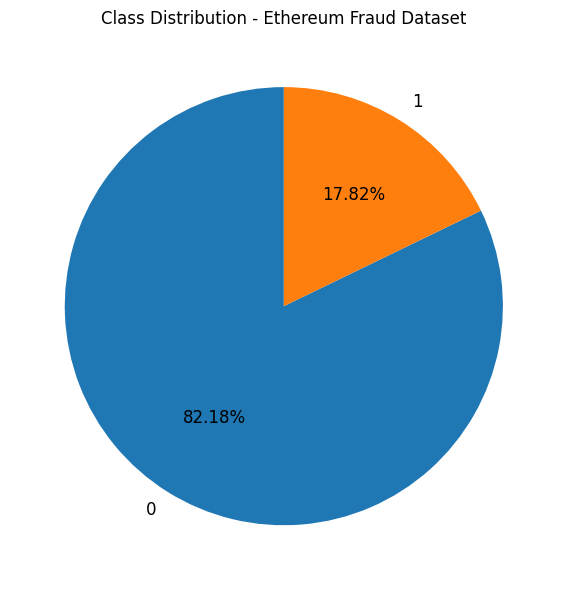

In [4]:
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean_datasets/ethereum/ethereum_fraud_clean.csv')

class_counts = df['class'].value_counts()
labels = class_counts.index.tolist()
sizes = class_counts.values

colors = ['#1f77b4', '#ff7f0e']  # blue for 0, orange for 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Class Distribution - Ethereum Fraud Dataset')
plt.tight_layout()
plt.show()

Based on the distribution of the cleaned dataset, it is clear that the data is highly imbalanced, with 82.18% licit and 17.82% illicit transactions. Because of this, a model that labels everything as "licit" would achieve high accuracy but would be useless for AML purposes. Therefore, accuracy will not be considered as the main metric. Instead, the focus will be on the F1-score, which balances precision and recall. Precision shows how many flagged transactions are actually illicit, while recall shows how many illicit transactions are correctly identified. In addition, ROC-AUC will be used to evaluate threshold-independent performance and allow a fair comparison of all models.

### **Random Forest**
---

In [5]:
from src.training import run_random_forest_experiments

rf_results_eth = run_random_forest_experiments("ethereum")
rf_results_eth

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,Random Forest,simple,0.946746,0.932836,0.755287,0.834725,0.980913
1,ethereum,Random Forest,simple_balanced,0.948359,0.946768,0.752266,0.838384,0.981206
2,ethereum,Random Forest,smote,0.943518,0.855346,0.821752,0.838213,0.978748


#### **Results:**
---

**F1-score:** We can see that is almost identical acroos all three set ups, which is very interesting as it shows that Random Forest dosent dramatically change the overall effectivness at detecting illicit transactions following the imbalance handling strategy

**Precision vs. Recall:** Simple and simple_balanced both achieve high precision  almos 95% but sacrifice recall 75%. SMOTE flips this balance precision drops to 85.5% but recall climbs to 82.2%. Since the F1 is essentially the same, the choice between setups becomes a practical decision about what kind of errors are more costly.

**ROC-AUC:** Again almost identtical with score around 97.8%-98% thus confirming that the model's ranking ability is strong across all setups and it can separate classes well regardless of threshold.

*For AML specifically, recall is arguably the more important metric as missing an illicit transaction (false negative) can have serious regulatory and financial consequences. That would make the **SMOTE** setup the most attractive here despite the precision drop.*

---
---

### **XGBoost**
---

In [6]:
from src.training import run_xgboost_experiments

xgBoost_results_eth = run_xgboost_experiments("ethereum")
xgBoost_results_eth

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:30:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:30:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:30:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,XGBoost,simple,0.956966,0.953069,0.797583,0.868421,0.988217
1,ethereum,XGBoost,simple_balanced,0.960194,0.890578,0.885196,0.887879,0.988229
2,ethereum,XGBoost,smote,0.953739,0.893891,0.839879,0.866044,0.984862


#### **Results:**
---

**F1-score:** Now varies more across setups, unlike Random Forest where it was nearly flat. The *simple_balanced* setup is the clear winner at 0.888, comparing to *simple* (0.868) and *SMOTE* (0.866). This tells us XGBoost responds more sensitively to how you handle class imbalance.

**Precision vs. Recall:** The *simple_balanced* setup hits the best balance. It achieves the best recall (0.885) while precision only drops to 0.891. Comparing to the *simple* setup, follows the expected pattern - high precision (0.953) but lower recall (0.798). It's conservative - very confident when it flags, but misses about 20% of illicit cases.

*SMOTE* doesn't help as much as expected. It improves recall over the *simple* setup (0.840 vs. 0.798) but doesn't reach the level of *simple_balanced* (0.885), and its F1 is actually the lowest of the three. This suggests that XGBoost's internal mechanism handles the imbalance more effectively than generating synthetic oversampling.

**ROC-AUC:** Is strong across all setups around (0.985–0.988), meaning XGBoost's ranking ability is excellent regardless of configuration.

***simple_balanced** is the best setup by a clear margin on the metrics with highest F1 and highest recall while having competitive precision.*

---
---

### **LightGBM**
---

In [7]:
from src.training import run_lightgbm_experiments

lightGbm_results_eth = run_lightgbm_experiments("ethereum")
lightGbm_results_eth

[LightGBM] [Info] Number of positive: 1325, number of negative: 6111
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4332
[LightGBM] [Info] Number of data points in the train set: 7436, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.178187 -> initscore=-1.528678
[LightGBM] [Info] Start training from score -1.528678
[LightGBM] [Info] Number of positive: 1325, number of negative: 6111
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001002 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4332
[LightGBM] [Info] Number of data points in the train set: 7436, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] 

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,LightGBM,simple,0.959656,0.957143,0.809668,0.877250,0.986681
1,ethereum,LightGBM,simple_balanced,0.963959,0.925806,0.867069,0.895476,0.988363
2,ethereum,LightGBM,smote,0.958042,0.914754,0.842900,0.877358,0.984650


#### **Results:**
---
*LightGBM on Ethereum follows a very similar pattern to XGBoost, which makes sense as they're both gradient boosting frameworks.*

***Simple_balanced*** is again the best setup, achieving the highest F1 (0.895) and the highest recall (0.867). Precision sits at 0.926, which is a very reasonable tradeoff - the model catches nearly 87% of illicit transactions while maintaining strong confidence in its flags.

The ***simple*** setup is again the most conservative with highest precision (0.957) but lowest recall (0.810). About 19% of illicit transactions go undetected.

***SMOTE*** again doesn't help as much as expected. Its recall (0.843) improves over simple but doesn't reach *simple_balanced*, and its precision (0.915) offers no advantage either. F1 (0.877) ties with the *simple* setup, making *SMOTE* the least attractive option here. Just like with XGBoost, the model's internal balancing mechanism outperforms synthetic oversampling.

**ROC-AUC:**  Is consistently strong (0.985–0.988), showing excellent ranking ability across all setups.

*All three models (Random Forest, XGBoost, LightGBM) show that their internal class-weighting mechanisms handle imbalance better than SMOTE. The **simple** setup always trades recall for precision, and **simple_balanced** consistently finds the best overall balance on the metrics that matter.*

---
---

### **Logistc Regression**
---

In [8]:
from src.training import run_logistic_regression_experiments

logisticRegression_results_eth = run_logistic_regression_experiments("ethereum")
logisticRegression_results_eth

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,Logistic Regression,scaled,0.822485,0.600000,0.009063,0.017857,0.775357
1,ethereum,Logistic Regression,scaled_balanced,0.553523,0.259865,0.815710,0.394161,0.769378
2,ethereum,Logistic Regression,scaled_smote,0.555137,0.260155,0.812689,0.394139,0.771751


#### **Results:**
---
*Logistic Regression on Ethereum has a dramatic performance drop compared to the tree-based models*

The ***scaled*** setup is essentially useless for AML. The F1 is 0.018 and recall is 0.009 this means the model catches less than 1% of illicit transactions. That 0.822 accuracy is a perfect example of why we dismissed accuracy as a metric: the model is just predicting almost everything as licit and getting "rewarded" for it by the imbalanced class distribution.

***Scaled_balanced*** and ***scaled_smote*** produce nearly identical results, both with F1 around 0.394, recall around 0.813–0.816, and precision around 0.260. The good thing here is that recall jumps massively with the model now catches about 81% of illicit cases. The bad thing though is that the **precision** is terrible: only about 26% of flagged transactions are actually illicit. That means roughly 3 out of every 4 flags are false alarms, which would overwhelm any investigation team.

**ROC-AUC:** Drops to  around 0.770–0.775, which is a substantial decline from the tree-based models that were all above 0.978. This confirms that Logistic Regression fundamentally struggles with this data - it likely can't capture the non-linear relationships and complex feature interactions that the tree-based models handle naturally.

*Logistic Regression is a poor fit for the Ethereum dataset. Even its best setups produce F1 scores less than half of what the tree-based models achieve.*

---

### **LinearSVC**
---

In [9]:
from src.training import run_linear_svc_experiments

linearSvc_results_eth= run_linear_svc_experiments("ethereum")
linearSvc_results_eth

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,Linear SVC,scaled,0.819796,0.000000,0.000000,0.000000,None
1,ethereum,Linear SVC,scaled_balanced,0.542227,0.255179,0.818731,0.389088,None
2,ethereum,Linear SVC,scaled_smote,0.544379,0.255218,0.812689,0.388448,None


#### **Results:**
---
*LinearSVC on Ethereum confirms and even shows more the pattern we saw with Logistic Regression that linear models simply cannot handle this problem.*

The ***scaled*** setup is completely non-functional. Precision, recall, and F1 are all exactly 0.000. The model predicts every single transaction as licit. It has learned nothing about the illicit class.

The ***Scaled_balanced*** and ***scaled_smote*** results are very similar, with an F1 score of about 0.389, recall around  0.813–0.819, and precision around 0.255. This is similar to Logistic Regression because both use linear decision boundaries. About 4 out of every 5 illicit transactions are caught, but nearly 3 out of 4 flags are false alarms.

The missing ***ROC AUC*** is a limitation worth noting. Without probability estimates, we lose the ability to tune the decision threshold, which reduces the model's practical flexibility in a real AML system.

*Comparing the two linear models on Ethereum: they perform almost identically when balanced or SMOTE is applied. The slight edge Logistic Regression has is the availability of ROC AUC around (0.770) and marginally better calibrated probabilities. **Neither is a viable choice for this task though**.*

*The data in Ethereum dataset contains non-linear patterns that linear models cannot capture, making tree-based models superior.*

---
---

### **Ethereum Overall:**
---

In [10]:
all_results_eth = pd.concat([rf_results_eth, xgBoost_results_eth, lightGbm_results_eth, logisticRegression_results_eth, linearSvc_results_eth])
all_results_eth

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,ethereum,Random Forest,simple,0.946746,0.932836,0.755287,0.834725,0.980913
1,ethereum,Random Forest,simple_balanced,0.948359,0.946768,0.752266,0.838384,0.981206
2,ethereum,Random Forest,smote,0.943518,0.855346,0.821752,0.838213,0.978748
0,ethereum,XGBoost,simple,0.956966,0.953069,0.797583,0.868421,0.988217
1,ethereum,XGBoost,simple_balanced,0.960194,0.890578,0.885196,0.887879,0.988229
2,ethereum,XGBoost,smote,0.953739,0.893891,0.839879,0.866044,0.984862
0,ethereum,LightGBM,simple,0.959656,0.957143,0.809668,0.877250,0.986681
1,ethereum,LightGBM,simple_balanced,0.963959,0.925806,0.867069,0.895476,0.988363
2,ethereum,LightGBM,smote,0.958042,0.914754,0.842900,0.877358,0.98465
0,ethereum,Logistic Regression,scaled,0.822485,0.600000,0.009063,0.017857,0.775357


#### **Results:**
---
There's a clear divide between model families as discussed above. The three tree-based models (Random Forest, XGBoost, LightGBM) all achieve F1 scores in the 0.834–0.895 range with ROC AUC above 0.978. The two linear models (Logistic Regression, LinearSVC) max out at F1 around 0.394 with ROC AUC around 0.770 (or unavailable). The tree-based models are more than twice as effective at detecting illicit transactions.

The best overall configuration on Ethereum is ***LightGBM simple_balanced***, achieving the highest F1 (0.895) across all 15 experiments. It pairs strong recall (0.867) with solid precision (0.926), meaning it catches the most illicit transactions while keeping false alarms manageable. ***XGBoost simple_balanced*** comes in a close second (F1 = 0.888, recall = 0.885). It actually has slightly higher recall but at the cost of more precision.

***Random Forest*** lags behind the other two tree-based models. Its best F1 is only 0.838 (SMOTE), and its recall never exceeds 0.822. It's still a lot better than the linear models, but it doesn't match the boosting methods.

On imbalance handling across all tree-based models, ***simple_balanced*** consistently outperforms or matches the other setups. ***SMOTE*** helps over the simple baseline but never beats the model's internal balancing mechanism. For the linear models, ***balanced/SMOTE*** is essential just to get any detection at all, but even then results are poor.

Linear models fail because of the nature of the data. Blockchain transaction features likely have complex, non-linear interactions that a linear decision boundary simply cannot separate. The tree-based models can partition the feature space in better ways that capture these patterns.

Having said that ***Ethereum LightGBM (simple_balanced)*** is the winner, tree-based models dominate, linear models are poor, and internal class balancing beats SMOTE.

---
---

## **ELLIPTIC++:**
---

The Elliptic++ dataset is a Bitcoin blockchain dataset designed for Anti-Money Laundering (AML) research. It was published at ACM SIGKDD 2023 (Georgia Tech) and supports detecting both fraudulent transactions and illicit wallet addresses. The dataset spans 49 temporal time steps, reflecting how the Bitcoin network evolves over time.

It consists of two sub-datasets:

---

### 1. **Actors (Wallet Addresses) Dataset**

- 822,942 unique addresses (1,268,260 address-time instances across 49 steps)
- Labels: Illicit (class 1) (14,266), Licit (class 2) (251,088), Unknown (class 3) (557,588)
- Graph: about 2.87M address-to-address edges + bipartite address-transaction edges
- 56 features per address covering: transaction counts, BTC amounts sent/received, fees, block spacing between transactions, and number of unique counterparties
- Task: Classify wallet addresses as illicit or licit
---

### 2. **Transactions Dataset**

- 203,769 transactions, each described by 183 features
- Labels: Illicit (class 1) (4,545), Licit (class 2)(42,019), Unknown (class 3)(157,205)
- Graph: 234,355 directed edges representing Bitcoin flow between transactions
- Features split into:
    - 93 local graph-embedding features
    - 72 aggregate graph-embedding features
    - 16 explicit Bitcoin features (fees, BTC amounts, input/output degree, etc.)
- Task: Classify transactions as illicit or licit
---

### **Elliptic Dataset Structure**
---

### **Transactions**

- txs_features.csv → transaction features
- txs_classes.csv → transaction labels
- txs_edgelist.csv → transaction graph

### **Wallets**

- wallets_features.csv → wallet features
- wallets_classes.csv → wallet labels
- wallets_features_classes_combined.csv → merged dataset

### **Graph Data**

- AddrAddr_edgelist.csv → address-address connections
- AddrTx_edgelist.csv → address-transaction links
- TxAddr_edgelist.csv → transaction-address links

## **Wallets-Features-Classes-Combined:**
---

In [11]:
from src.data_loader import _load_raw_elliptic_wallets_combined

wallets_combined = _load_raw_elliptic_wallets_combined()
wallets_combined

,address,Time step,class,num_txs_as_sender,num_txs_as receiver,first_block_appeared_in,last_block_appeared_in,lifetime_in_blocks,total_txs,first_sent_block,...,blocks_btwn_output_txs_min,blocks_btwn_output_txs_max,blocks_btwn_output_txs_mean,blocks_btwn_output_txs_median,num_addr_transacted_multiple,transacted_w_address_total,transacted_w_address_min,transacted_w_address_max,transacted_w_address_mean,transacted_w_address_median
0,111112TykSw72ztDN2WJger4cynzWYC5w,25,2,0.0,1.0,439586.0,439586.0,0.0,1.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,24.0,1.0,1.0,1.0,1.0
1,1111DAYXhoxZx2tsRnzimfozo783x1yC2,25,3,0.0,8.0,439589.0,485959.0,46370.0,8.0,0.0,...,0.0,20164.0,6624.285714,8060.0,0.0,8.0,1.0,1.0,1.0,1.0
2,1111DAYXhoxZx2tsRnzimfozo783x1yC2,29,3,0.0,8.0,439589.0,485959.0,46370.0,8.0,0.0,...,0.0,20164.0,6624.285714,8060.0,0.0,8.0,1.0,1.0,1.0,1.0
3,1111DAYXhoxZx2tsRnzimfozo783x1yC2,39,3,0.0,8.0,439589.0,485959.0,46370.0,8.0,0.0,...,0.0,20164.0,6624.285714,8060.0,0.0,8.0,1.0,1.0,1.0,1.0
4,1111DAYXhoxZx2tsRnzimfozo783x1yC2,39,3,0.0,8.0,439589.0,485959.0,46370.0,8.0,0.0,...,0.0,20164.0,6624.285714,8060.0,0.0,8.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268255,3R2Uw5MRdSSigp8AjfT7K5es6Hupm4qLSq,31,3,1.0,1.0,451684.0,451685.0,1.0,2.0,451685.0,...,0.0,0.0,0.000000,0.0,0.0,3.0,1.0,1.0,1.0,1.0
1268256,3R2VBFbqHGC4bQ7b4ixN4jZTdv7RMbEYtf,44,3,0.0,1.0,477895.0,477895.0,0.0,1.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1268257,3R2WFmRwbDeo3rMVVu5J3jjMxAuQYYWAid,9,3,0.0,1.0,407342.0,407342.0,0.0,1.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1268258,3R2WTZGYLmbJQyoDSBftJsPRvF1mSEtkh6,3,3,0.0,1.0,395235.0,395235.0,0.0,1.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,1.0,1.0,1.0,1.0,1.0


### **Cleaning Process - Wallets:**
---

**Steps:**
1. Drop identifier columns - Adress
2. Drop Time step - A wallet can appear in many time steps because it makes transactions over time. If all rows are kept, the same wallet is repeated with slightly different values. By removing the time step, each wallet is kept only once, and duplicates are removed. The goal is to classify each wallet based on its features, not over time.
3. Remove duplicates
4. Remove unknown class (class = 3) - About 75% of wallets have no label (class 3). Since there is no known information about them, they cannot be used for training or evaluating supervised models.
5. Rename class 2 -> 0 - The dataset uses labels 1 for illicit, 2 for licit, and 3 for unknown. For binary classification, labels should be 0 and 1. So, licit is changed to 0 and illicit stays as 1.

---
---

### **Loading Process - Wallets:**
---

- Load raw combined dataset (features + classes)
- Preprocess data and save cleaned version
- Load cleaned dataset
- Split into features (X) and target (y)
- Apply random stratified train/test split
- Apply scaling using StandardScaler for Linear Models
- Apply SMOTE on training data for some Experiments
- For experiments using both Scale first, then apply SMOTE

---
---

In [12]:
from src.data_loader import _load_preprocessed_elliptic_wallets_combined

wallets_combined_cleaned = _load_preprocessed_elliptic_wallets_combined()
wallets_combined_cleaned

,class,num_txs_as_sender,num_txs_as receiver,first_block_appeared_in,last_block_appeared_in,lifetime_in_blocks,total_txs,first_sent_block,first_received_block,num_timesteps_appeared_in,...,blocks_btwn_output_txs_min,blocks_btwn_output_txs_max,blocks_btwn_output_txs_mean,blocks_btwn_output_txs_median,num_addr_transacted_multiple,transacted_w_address_total,transacted_w_address_min,transacted_w_address_max,transacted_w_address_mean,transacted_w_address_median
0,0,0.0,1.0,439586.0,439586.0,0.0,1.0,0.0,439586.0,1.0,...,0.0,0.0,0.0,0.0,0.0,24.0,1.0,1.0,1.0,1.0
1,0,0.0,1.0,431522.0,431522.0,0.0,1.0,0.0,431522.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
2,0,0.0,1.0,429513.0,429513.0,0.0,1.0,0.0,429513.0,1.0,...,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,1.0,1.0
3,0,1.0,1.0,399269.0,399271.0,2.0,2.0,399271.0,399269.0,1.0,...,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,1.0
4,0,0.0,1.0,423462.0,423462.0,0.0,1.0,0.0,423462.0,1.0,...,0.0,0.0,0.0,0.0,0.0,11.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243179,0,0.0,1.0,465794.0,465794.0,0.0,1.0,0.0,465794.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
243180,0,0.0,1.0,411364.0,411364.0,0.0,1.0,0.0,411364.0,1.0,...,0.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0
243181,0,0.0,1.0,435555.0,435555.0,0.0,1.0,0.0,435555.0,1.0,...,0.0,0.0,0.0,0.0,0.0,5.0,1.0,1.0,1.0,1.0
243182,0,0.0,1.0,437572.0,437572.0,0.0,1.0,0.0,437572.0,1.0,...,0.0,0.0,0.0,0.0,0.0,11.0,1.0,1.0,1.0,1.0


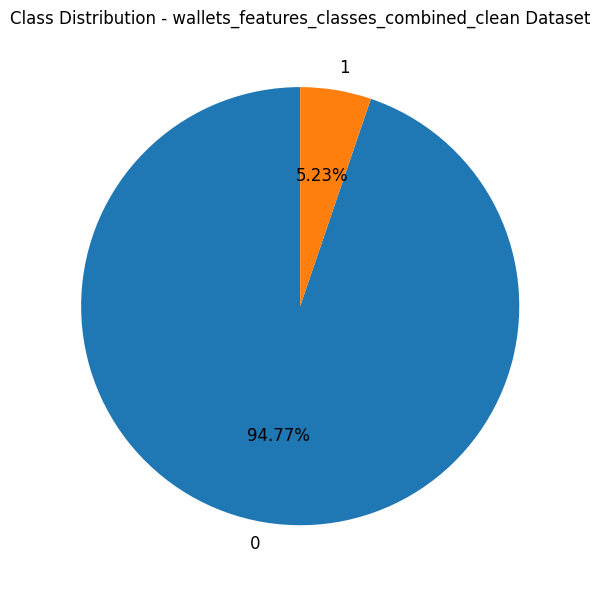

In [13]:
df = pd.read_csv('../data/clean_datasets/elliptic_plus_plus/wallets_features_classes_combined_clean.csv')

class_counts = df['class'].value_counts()
labels = class_counts.index.tolist()
sizes = class_counts.values

colors = ["#1f77b4", "#ff7f0e"]  # blue for 0, orange for 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Class Distribution - wallets_features_classes_combined_clean Dataset')
plt.tight_layout()
plt.show()

Again based on the distribution of the cleaned dataset, it is clear that the data is highly imbalanced, with 94.77% licit and 5.23% illicit transactions. Because of this, a model that labels everything as "licit" would achieve high accuracy but would be useless for AML purposes. Therefore, accuracy will not be considered as the main metric. Instead, the focus will be on the F1-score, which balances precision and recall. Precision shows how many flagged transactions are actually illicit, while recall shows how many illicit transactions are correctly identified. In addition, ROC-AUC will be used to evaluate threshold-independent performance and allow a fair comparison of all models.

### **Random Forest**
---

In [14]:
rf_results_wallets = run_random_forest_experiments("elliptic-wallets-combined")
rf_results_wallets

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest,simple,0.989103,0.838469,0.715538,0.772141,0.979037
1,elliptic-wallets-combined,Random Forest,simple_balanced,0.989411,0.858527,0.705976,0.774814,0.981216
2,elliptic-wallets-combined,Random Forest,smote,0.977877,0.547180,0.827092,0.658629,0.981756


#### **Results:**
---

***Simple and simple_balanced*** are nearly identical with F1 scores of 0.772 and 0.775 respectively and very similar precision around (0.838–0.859) and recall around (0.706–0.716). The internal balancing mechanism barely makes a difference here, showing that the class imbalance may not be the main challenge Random Forest faces on this dataset.

***SMOTE*** is clearly harmful. It boosts recall to 0.827 but at a very big cost to precision (0.547), dragging F1 down to 0.659. The synthetic oversampling most probably is introducing noise that blurs the decision boundary, making the model flag too many licit transactions.

**ROC-AUC** is consistently strong (0.979–0.982), meaning the model can rank transactions well but struggles to find an optimal threshold for classification.

*Random Forest on Elliptic++ wallets-combined has simple_balanced as the best setup, but the advantage over simple is negligible. SMOTE should be avoided as it performs poorly inspite the fact that is improving recall.*

---
---

### **XGBoost**
---

In [15]:
xgBoost_results_wallets = run_xgboost_experiments("elliptic-wallets-combined")
xgBoost_results_wallets

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:32:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:32:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:32:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,XGBoost,simple,0.987849,0.802368,0.701992,0.748831,0.981587
1,elliptic-wallets-combined,XGBoost,simple_balanced,0.957687,0.367185,0.884462,0.518934,0.981937
2,elliptic-wallets-combined,XGBoost,smote,0.960318,0.381120,0.862151,0.528578,0.977463


#### **Results:**
---

The ***simple*** setup is actually the best by F1 (0.749), which is a notable shift. It achieves high precision (0.802) with moderate recall (0.702). This is the most balanced tradeoff of the three setups.

***Simple_balanced*** and ***SMOTE*** both collapse in precision. When balancing is applied, precision drops dramatically to  around 0.367–0.381 while recall jumps to  around 0.862–0.884. The resulting F1 scores (0.519 and 0.529) are substantially worse than the ***simple*** setup. This means the balancing strategies cause XGBoost to massively over flag with roughly 2 out of 3 flagged transactions are false alarms.

On this dataset, XGBoost's internal mechanism seems to overcorrect, flooding the predictions with false positives. The data characteristics clearly influence how well balancing strategies work.

**ROC-AUC** remains excellent across all setups (0.977–0.982), so the model's ranking ability is strong..

*The simple setup wins by a clear margin on F1. The balancing strategies hurt more than they help, suggesting that for this particular data, XGBoost performs best when left to handle the class distribution on its own without explicit corrections.*

---
---

### **LightGBM**
---

In [16]:
lightGbm_results_wallets = run_lightgbm_experiments("elliptic-wallets-combined")
lightGbm_results_wallets

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11463, number of negative: 183084
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11865
[LightGBM] [Info] Number of data points in the train set: 194547, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058921 -> initscore=-2.770821
[LightGBM] [Info] Start training from score -2.770821
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11463, number of negative: 183084
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11865
[LightGBM] [Info] Number of data points in the train set: 194547, number o

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,LightGBM,simple,0.988424,0.807829,0.723506,0.763346,0.983293
1,elliptic-wallets-combined,LightGBM,simple_balanced,0.961655,0.392832,0.890837,0.545233,0.985087
2,elliptic-wallets-combined,LightGBM,smote,0.965109,0.413941,0.847012,0.556108,0.979239


#### **Results:**
---

**F1-score:** The ***simple*** setup is the clear winner at 0.763, while ***simple_balanced*** (0.545) and ***SMOTE*** (0.556) are far behind. This mirrors exactly what we saw with XGBoost on this dataset with the balancing strategies hurt overall effectiveness.

**Precision vs Recall:** The ***simple*** setup holds strong precision (0.808) with average recall (0.724). When balancing is applied, the same pattern as XGBoost repeats: precision crashes to  around 0.393–0.414 while recall jumps to around 0.847–0.891. This means the model detects more illicit transactions but also makes many more false alarms, roughly 6 out of 10 transactions incorrectly.

**ROC-AUC** The score is consistently high (0.979–0.985), which shows that ***LightGBM*** can rank transactions well in all setups. The problem is not the model’s ability to distinguish between classes, but choosing the right threshold when balancing is applied.

*Simple setup is the best by a lot on F1. On this dataset, both boosting models (XGBoost and LightGBM) react similarly, their internal balancing mechanisms overcorrect and making predictions having a lot of false positives. This contrasts with Random Forest, where simple and simple_balanced were nearly the same.*

---
---

### **Logistic Regression**
---

In [17]:
logisticRegression_results_wallets = run_logistic_regression_experiments("elliptic-wallets-combined")
logisticRegression_results_wallets

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Logistic Regression,scaled,0.975225,0.576687,0.149801,0.237824,0.833747
1,elliptic-wallets-combined,Logistic Regression,scaled_balanced,0.894257,0.146288,0.640637,0.238187,0.846151
2,elliptic-wallets-combined,Logistic Regression,scaled_smote,0.897239,0.150383,0.641434,0.243644,0.849546


#### **Results:**
---

**F1-score:** All three setups produce very low F1 scores. There is virtually no meaningful difference between them. The model is performing poor even though of how imbalance is handled.

**Precision vs Recall:** The ***scaled*** setup has higher precision (0.577) but very low recall (0.150), it barely detects any illicit transactions. ***Scaled_balanced*** and ***scaled_smote*** flip this: precision drops to around 0.146–0.150 while recall jumps to around 0.641. But both combinations does not works well. The ***scaled*** setup misses 85% of illicit cases, while the ***balanced*** setups flag roughly 8 to 9 out of 10 flagged transactions incorrectly. No setup achieves an acceptable tradeoff.

**ROC-AUC** The score is around 0.834–0.850. This shows the model can distinguish between classes to some extent, but it still performs much worse than tree-based models, which all score above 0.977.

*Logistic Regression is poor for this dataset. All three setups produce F1 scores below 0.25, meaning the model would be essentially useless in a real AML setting. The linear decision boundary simply cannot capture the complexity of the wallet-level features.*

---
---

### **LinearSVC**
---

In [18]:
linearSvc_results_wallets = run_linear_svc_experiments("elliptic-wallets-combined")
linearSvc_results_wallets

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Linear SVC,scaled,0.974484,0.535000,0.085259,0.147079,None
1,elliptic-wallets-combined,Linear SVC,scaled_balanced,0.895943,0.144033,0.613546,0.233298,None
2,elliptic-wallets-combined,Linear SVC,scaled_smote,0.897650,0.146707,0.615936,0.236971,None


#### **Results:**
---

**F1-score:** The worst performance we've seen yet. ***Scaled*** produces an F1 of just 0.147, while ***scaled_balanced*** (0.233) and ***scaled_smote*** (0.237) are only a little bit better. None of these are good.

**Precision vs Recall:** The same pattern as Logistic Regression but even worse. The ***scaled**** setup has average precision (0.535) but near-zero recall (0.085), it catches fewer than 1 in 10 illicit transactions. ***Scaled_balanced*** and ***scaled_smote*** improve recall to around 0.614–0.616, but precision collapses to around 0.144–0.147, meaning about 8 to 9 out of 10 flags are wrong.

*LinearSVC is the weakest model on this dataset. It performs even worse than Logistic Regression across all setups, confirming again that linear models are basically not good fit for this classification task. Also the lack of ROC-AUC reduces its practical value compared to Logistic Regression.*

---
---

### **Wallets Overall:**
---

In [19]:
all_results_wallets = pd.concat([rf_results_wallets, xgBoost_results_wallets, lightGbm_results_wallets, 
                                 logisticRegression_results_wallets, linearSvc_results_wallets])
all_results_wallets

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest,simple,0.989103,0.838469,0.715538,0.772141,0.979037
1,elliptic-wallets-combined,Random Forest,simple_balanced,0.989411,0.858527,0.705976,0.774814,0.981216
2,elliptic-wallets-combined,Random Forest,smote,0.977877,0.547180,0.827092,0.658629,0.981756
0,elliptic-wallets-combined,XGBoost,simple,0.987849,0.802368,0.701992,0.748831,0.981587
1,elliptic-wallets-combined,XGBoost,simple_balanced,0.957687,0.367185,0.884462,0.518934,0.981937
2,elliptic-wallets-combined,XGBoost,smote,0.960318,0.381120,0.862151,0.528578,0.977463
0,elliptic-wallets-combined,LightGBM,simple,0.988424,0.807829,0.723506,0.763346,0.983293
1,elliptic-wallets-combined,LightGBM,simple_balanced,0.961655,0.392832,0.890837,0.545233,0.985087
2,elliptic-wallets-combined,LightGBM,smote,0.965109,0.413941,0.847012,0.556108,0.979239
0,elliptic-wallets-combined,Logistic Regression,scaled,0.975225,0.576687,0.149801,0.237824,0.833747


#### **Results:**
---

The same clear divide between model families appears again. Tree-based models (Random Forest, XGBoost, LightGBM) all achieve F1 scores between 0.659 and 0.775 with ROC-AUC above 0.977. Linear models (Logistic Regression, LinearSVC) are far behind, with F1 scores never passing 0.244 and ROC-AUC at 0.850 or unavailable. Tree-based models are roughly three times more effective at detecting illicit wallets.

The best overall configuration is ***Random Forest simple_balanced***, having the highest F1 (0.775) across all 15 experiments. It also has good precision (0.859) with reasonable recall (0.706), meaning it makes reliable flags while still catching an okay portion of illicit wallets. ***Random Forest simple*** comes in a very close (F1 = 0.772) with nearly simillar performance.

Worth noting is that on this dataset the balancing strategies hurt the boosting models. Both ***XGBoost*** and ***LightGBM*** perform best with the simple setup (F1 = 0.749 and 0.763). When ***simple_balanced*** or ***SMOTE*** is applied, their precision crashes to around 0.367–0.414 while recall jumps, but the tradeoff is too extreme and F1 drops significantly. This is a different behaviour from ***Ethereum***, where ***simple_balanced*** helped these models. It shows that the best imbalance strategy depends on the dataset, not just the model.

***Random Forest*** is the most stable model on this dataset. Its ***simple and simple_balanced*** results are almost the same, and even its ***SMOTE*** result with F1 being 0.659.

Linear models are again useless. Both ***Logistic Regression and LinearSVC*** produce F1 scores below 0.25 in all setups. A linear decision boundary cannot capture the patterns in this wallet-level data.

All in all ***Random Forest (simple_balanced)*** is the winner, tree-based models dominate, linear models fail, and unlike Ethereum, explicit balancing hurts the boosting models on this dataset.

---
---

## **Transactions-Features-Classes-Combined:**

In [20]:
from src.data_loader import _load_raw_elliptic_transactions_features
from src.data_loader import _load_raw_elliptic_transactions_classes

raw_trn_features = _load_raw_elliptic_transactions_features()
raw_trn_features

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
raw_trn_classes = _load_raw_elliptic_transactions_classes()
raw_trn_classes

,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2
...,...,...
203764,158304003,3
203765,158303998,3
203766,158303966,3
203767,161526077,3


In [22]:
from src.data_loader import _load_raw_elliptic_transactions_combined

trn_combined = _load_raw_elliptic_transactions_combined()
trn_combined

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


### **Cleaning Process - Transactions:**
---

**Steps:**
1. Drop identifier columns - txId
2. Drop NaN rows
3. Remove unknown class (class = 3) - About 75% of wallets have no label (class 3). Since there is no known information about them, they cannot be used for training or evaluating supervised models.
4. Rename class 2 -> 0 - The dataset uses labels 1 for illicit, 2 for licit, and 3 for unknown. For binary classification, labels should be 0 and 1. So, licit is changed to 0 and illicit stays as 1.

---
---

### **Loading Process - Transactions:**
---

- Load raw transaction features
- Load raw transaction classes
- Merge features and classes on txId
- Preprocess merged dataset and save cleaned version
- Load cleaned dataset
- Split into features (X) and target (y)
- Apply time-based train/test split using Time step
- Remove Time step from features
- Apply selective scaling to specific columns for Linear Models - 168 onwards
- Apply SMOTE on training data for some Experiments
- For experiments using both Scale first, then apply SMOTE
---
---

In [23]:
from src.data_loader import _load_preprocessed_elliptic_transactions_combined

trn_combined_cleaned = _load_preprocessed_elliptic_transactions_combined()
trn_combined_cleaned

,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,-0.118555,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,0
1,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,5.252974,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,0
2,1,-0.172726,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163383,-0.169201,...,0.040774,0.040774,0.040774,0.040774,9.480000e-04,0.039726,0.020337,0.020337,0.040674,0
3,1,-0.172921,-0.158783,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.163581,-0.169397,...,0.010000,0.010000,0.010000,0.010000,2.900000e-03,0.006900,0.004900,0.004900,0.009800,0
4,1,-0.169967,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160559,-0.166417,...,0.478277,0.478277,0.478277,0.478277,4.630000e-02,0.431877,0.239088,0.239088,0.478177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46040,49,-0.039416,-0.118083,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.026985,-0.034715,...,21.175927,21.175927,21.175927,21.175927,4.005752e-02,21.135512,10.587785,10.587785,21.175569,0
46041,49,-0.050308,-0.112834,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.038129,-0.045703,...,19.449182,19.449182,19.449182,19.449182,1.000000e-02,19.438805,9.724402,9.724402,19.448805,0
46042,49,-0.154605,-0.116753,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.144840,-0.150918,...,2.914019,2.914019,2.914019,2.914019,3.886639e-01,2.524993,1.456828,1.456828,2.913657,0
46043,49,0.708000,-0.118083,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,0.737731,0.719284,...,139.670987,139.670987,139.670987,139.670987,1.018483e-01,139.568782,69.835315,69.835315,139.670630,0


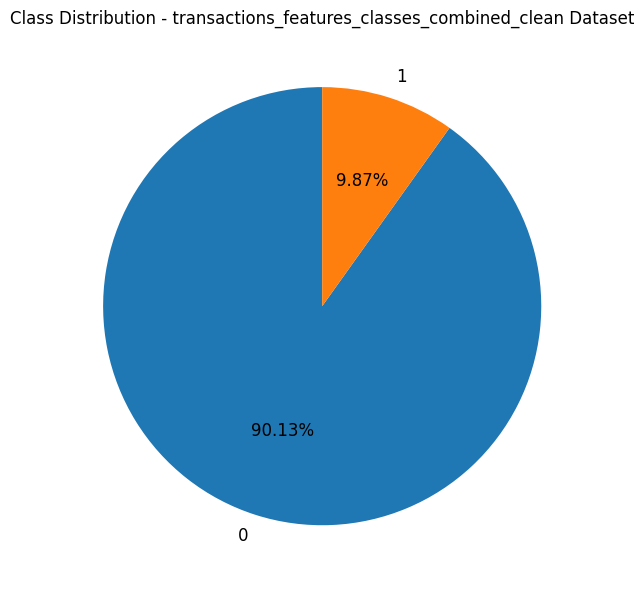

In [24]:
df = pd.read_csv('../data/clean_datasets/elliptic_plus_plus/transactions_features_classes_combined_clean.csv')

class_counts = df['class'].value_counts()
labels = class_counts.index.tolist()
sizes = class_counts.values

colors = ["#1f77b4", "#ff7f0e"]  # blue for 0, orange for 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Class Distribution - transactions_features_classes_combined_clean Dataset')
plt.tight_layout()
plt.show()

### **Random Forest**
---

In [25]:
rf_results_trn = run_random_forest_experiments("elliptic-transactions-combined")
rf_results_trn

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,Random Forest,simple,0.975133,0.961905,0.477541,0.638231,0.907953
1,elliptic-transactions-combined,Random Forest,simple_balanced,0.975024,0.957346,0.477541,0.637224,0.934442
2,elliptic-transactions-combined,Random Forest,smote,0.974916,0.952830,0.477541,0.636220,0.951151


#### **Results:**
---

**F1-score:** All three setups give almost the same F1 scores around (0.64). This means that using balancing or SMOTE does not significantly change the performance of Random Forest on this dataset.

**Precision vs Recall:** The recall is exactly 0.477541 across all three setups which is very weird to me. The model catches fewer than half of illicit transactions regardless of how imbalance is handled. Precision is very high (~0.953–0.962), meaning when it does flag something it's almost always correct, but it's far too conservative. Random Forest most probably learned a set of rules that identify a specific subset of illicit transactions while completely ignoring the rest.

**ROC-AUC** There is a clear difference between the setups. ***Simple*** scores 0.908, ***simple_balanced*** improves to 0.934, and ***SMOTE*** reaches 0.951. TThis shows that balancing improves the model’s ability to rank transactions. However, this improvement does not lead to better F1, precision, or recall at the default threshold. Better results might be achieved by adjusting the decision threshold, especially for the SMOTE setup.

*Random Forest is not affected much by balancing on this dataset. The same recall across all setups suggests the model uses fixed rules that do not change with class weighting or oversampling. It has high precision but low recall, meaning it detects the obvious illicit transactions but misses the more difficult ones.*

---
---

### **XGBoost**
---

In [26]:
xgBoost_results_trn = run_xgboost_experiments("elliptic-transactions-combined")
xgBoost_results_trn

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,XGBoost,simple,0.975133,0.961905,0.477541,0.638231,0.941273
1,elliptic-transactions-combined,XGBoost,simple_balanced,0.971658,0.818898,0.491726,0.614476,0.941776
2,elliptic-transactions-combined,XGBoost,smote,0.975133,0.949074,0.484634,0.641628,0.943208


#### **Results:**
---

**F1-score:** All three setups are close with ***simple*** (0.638), ***SMOTE*** (0.642), and ***simple_balanced*** (0.614). ***SMOTE*** is slightly the best, but the differences are small. ***Simple_balanced*** actually performs the worst, which is unusual for XGBoost.

**Precision vs Recall:** The pattern is very similar to Random Forest. Recall stays low across all setups around (0.478–0.485), meaning the model misses more than half of illicit transactions. Precision is high around (0.819–0.962), so when it flags something, it is usually correct. ***Simple_balanced*** drops precision to 0.819 without gaining much recall (0.492), which explains its lower F1.

**ROC-AUC** Very consistent at around 0.941–0.943 across all setups. The model ranks transactions well, but like Random Forest, this ranking ability does not lead to better classification at the default threshold.

*XGBoost behaves very similarly to Random Forest on this dataset. All setups struggle with the same problem with low recall. The model is good at catching the "easy" illicit transactions but misses the harder ones. SMOTE gives a tiny edge in F1 but the improvement is not significant.*

---
---

### **LightGBM**
---

In [27]:
lightGbm_results_trn = run_lightgbm_experiments("elliptic-transactions-combined")
lightGbm_results_trn

[LightGBM] [Info] Number of positive: 4122, number of negative: 32714
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42275
[LightGBM] [Info] Number of data points in the train set: 36836, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111901 -> initscore=-2.071465
[LightGBM] [Info] Start training from score -2.071465
[LightGBM] [Info] Number of positive: 4122, number of negative: 32714
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42275
[LightGBM] [Info] Number of data points in the train set: 36836, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM]

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,LightGBM,simple,0.974916,0.957143,0.475177,0.635071,0.946200
1,elliptic-transactions-combined,LightGBM,simple_balanced,0.974590,0.912664,0.494090,0.641104,0.948937
2,elliptic-transactions-combined,LightGBM,smote,0.975676,0.954338,0.494090,0.651090,0.959254


#### **Results:**
---

**F1-score:** ***SMOTE*** is the best setup (0.651), followed by ***simple_balanced*** (0.641) and ***simple*** (0.635). The differences are small but ***SMOTE*** has a slight edge.

**Precision vs Recall:** The same low-recall problem appears here as well. Recall sits around 0.475–0.494 across all setups with the model still misses about half of illicit transactions. Precision stays high between (0.913–0.957). ***Simple_balanced*** and ***SMOTE*** both push recall slightly higher (0.494) compared to ***simple*** (0.475), but the improvement is little.

**ROC-AUC:** Ranges from 0.946 to 0.959, with ***SMOTE*** scoring the highest. This is slightly better than both Random Forest and XGBoost on this dataset, showing LightGBM has the best ranking ability of the three tree-based models here.

*LightGBM follows the same overall pattern as Random Forest and XGBoost — high precision, low recall. However, it responds slightly better to balancing strategies. SMOTE gives the best F1 and the best ROC-AUC, making it the best setup. All three tree-based models struggle with recall, which suggests that the problem comes from the data, not the model.*

---
---

### **Logistic Regression**
---

In [28]:
logisticRegression_results_trn = run_logistic_regression_experiments("elliptic-transactions-combined")
logisticRegression_results_trn

c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,Logistic Regression,scaled,0.955153,0.512376,0.489362,0.500605,0.862734
1,elliptic-transactions-combined,Logistic Regression,scaled_balanced,0.847975,0.181759,0.659574,0.284985,0.874600
2,elliptic-transactions-combined,Logistic Regression,scaled_smote,0.871104,0.207504,0.640662,0.313476,0.876963


#### **Results:**
---

**F1-score:** The ***scaled*** setup actually performs best (0.501), while ***scaled_balanced*** (0.285) and ***scaled_smote*** (0.313) are much worse. This is surprising because balancing makes things worse here.

**Precision vs Recall:** The ***scaled*** setup finds a reasonable middle ground with precision (0.512) and recall (0.489) both around 50%. It's not great, but at least it's balanced. When balancing is applied, precision drops sharply to around 0.182–0.208 while recall increases to around 0.641–0.660. This means about 8 out of 10 flags are wrong, which is useless in practice.

**ROC-AUC:** Ranges from 0.863 to 0.877, which is actually better than what Logistic Regression achieved on the previous two datasets. The model has some ability to separate the classes, but it still falls behind the tree-based models (all above 0.907).

*Logistic Regression performs poorly, but the best results come from the scaled setup without balancing. Although the F1 score (0.501) is better than in the wallets dataset (0.244), it is still much lower than the tree-based models.*

---
---

### **Linear SVC**
---

In [29]:
linearSvc_results_trn = run_linear_svc_experiments("elliptic-transactions-combined")
linearSvc_results_trn

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,Linear SVC,scaled,0.962537,0.623418,0.465721,0.533153,None
1,elliptic-transactions-combined,Linear SVC,scaled_balanced,0.894994,0.240952,0.598109,0.343517,None
2,elliptic-transactions-combined,Linear SVC,scaled_smote,0.908568,0.270537,0.583924,0.369760,None


#### **Results:**
---

**F1-score:** The ***scaled*** setup is again the best (0.533), while ***scaled_balanced*** (0.344) and ***scaled_smote*** (0.370) fell. Same pattern as Logistic Regression, balancing hurts more than it helps.

**Precision vs Recall:** The ***scaled*** setup has the best balance with precision (0.623) and recall (0.466). When balancing is applied, precision drops to around 0.241–0.271 while recall increases between 0.584–0.598. The tradeoff is too costly with roughly 3 out of 4 flags become false alarms.

*LinearSVC actually performs better on this dataset than on the previous two. Its best F1 (0.533) is close to Logistic Regression's best (0.501), and interestingly it even slightly beats it. Both linear models follow the same pattern here which the plain scaled setup works best, and balancing strategies make things worse. The 5-minute training time also shows that LinearSVC is computationally expensive on this larger dataset, which is another practical disadvantage.*

---
---

### **Transactions Overall:**
---

In [30]:
all_results_trn = pd.concat([rf_results_trn, xgBoost_results_trn, lightGbm_results_trn, 
                                logisticRegression_results_trn, linearSvc_results_trn])
all_results_trn

,dataset,model,setup,accuracy,precision,recall,f1,roc_auc
0,elliptic-transactions-combined,Random Forest,simple,0.975133,0.961905,0.477541,0.638231,0.907953
1,elliptic-transactions-combined,Random Forest,simple_balanced,0.975024,0.957346,0.477541,0.637224,0.934442
2,elliptic-transactions-combined,Random Forest,smote,0.974916,0.952830,0.477541,0.636220,0.951151
0,elliptic-transactions-combined,XGBoost,simple,0.975133,0.961905,0.477541,0.638231,0.941273
1,elliptic-transactions-combined,XGBoost,simple_balanced,0.971658,0.818898,0.491726,0.614476,0.941776
2,elliptic-transactions-combined,XGBoost,smote,0.975133,0.949074,0.484634,0.641628,0.943208
0,elliptic-transactions-combined,LightGBM,simple,0.974916,0.957143,0.475177,0.635071,0.9462
1,elliptic-transactions-combined,LightGBM,simple_balanced,0.974590,0.912664,0.494090,0.641104,0.948937
2,elliptic-transactions-combined,LightGBM,smote,0.975676,0.954338,0.494090,0.651090,0.959254
0,elliptic-transactions-combined,Logistic Regression,scaled,0.955153,0.512376,0.489362,0.500605,0.862734


#### **Results:**
---

The gap between tree-based and linear models is smaller on this dataset compared to the previous two. Tree-based models achieve F1 scores between 0.614 and 0.651, while linear models reach 0.501–0.533. The difference is still clear, but linear models are not that behind as before.

The best overall setup is ***LightGBM*** with ***SMOTE***, which achieves the highest F1 score (0.651). It has high precision (0.954), average recall (0.494), and the highest ROC-AUC (0.959). However, the difference is small, as ***XGBoost*** with ***SMOTE*** and ***Random Forest*** with the ***simple setup*** have similar performance.

All tree-based models have the same main problem on this dataset, which is low recall. No setup reaches recall above 0.494, so more than half of illicit transactions are not detected. Precision is high, meaning the models are usually correct when they flag something, but they are too conservative. This suggests that illicit transactions in this dataset are harder to distinguish from licit ones.

Balancing strategies have different effects depending on the model. ***SMOTE*** slightly improves ***LightGBM*** and ***XGBoost***. For ***Random Forest***, balancing does not change recall. For linear models, balancing makes performance worse. Overall, there is no single best balancing method for all models.

Linear models perform poorly but not as badly as before. ***LinearSVC scaled*** (F1 = 0.533) and ***Logistic Regression scaled*** (F1 = 0.501) are the best linear setups. Both work better without balancing on this dataset, which is the opposite of what happened on Ethereum.

Overall, ***LightGBM with SMOTE*** performs best, but the difference between tree-based models is small. All models have low recall, showing that this dataset is more difficult. Linear models are still weaker, but the difference is smaller than in other datasets.

---
---

## ***Research Question: How do different feature-based models perform while detecting money laundering activities in more traditional data representations?***

The findings across all three datasets and five models give a clear answer.

**Tree-based models are far better than linear models for detecting money laundering.** Random Forest, XGBoost, and LightGBM outperform Logistic Regression and LinearSVC on every dataset. On **Ethereum**, tree-based models achieved F1 scores above 0.834 while linear models could not pass 0.394. On **Elliptic++ wallets-combined**, tree-based models reached 0.775 while linear models stayed below 0.244. On **Elliptic++ transactions-combined**, the gap was smaller but still clear with 0.651 on tree based models versus 0.533 on linear models. The reason is simple, money laundering patterns in transaction data involve complex, non-linear relationships between features that linear decision boundaries cannot capture.

From the tree-based models, **no single model dominates across all datasets**. **LightGBM** with ***simple_balanced*** was the best on **Ethereum** (F1 = 0.895). **Random Forest** with ***simple_balanced*** won on **Elliptic++ wallets-combined** (F1 = 0.775). **LightGBM** with ***SMOTE*** was the best on **Elliptic++ transactions-combined*** (F1 = 0.651). This means the best model depends on the dataset. However, **LightGBM** appeared as the winner on two out of three datasets, making it the most reliable choice overall.

The best strategy for **handling class imbalance also depends on the dataset**. On **Ethereum**, the models' internal balancing mechanisms ***(simple_balanced)*** worked best for all tree-based models. On **Elliptic++ wallets-combined**, *balancing actually hurt the boosting models* and only helped a little **Random Forest**. On **Elliptic++ transactions-combined**, ***SMOTE*** gave a slight edge to the ***boosting models*** while **Random Forest** was completely unaffected. There is no universal best approach and the right imbalance strategy must be tested for each dataset.

Linear models are not suitable for this task. **Logistic Regression and LinearSVC** consistently failed to find a good balance between **precision and recall**. **Without balancing**, they predicted almost everything as licit. **With balancing**, they flagged too many licit transactions as illicit. The missing ROC-AUC for **LinearSVC** further reduce their practical value. **These models should not be used for money laundering detection in these data representations**.

Dataset difficulty varies significantly. **The Ethereum** dataset was the ***easiest*** to classify, with the best models achieving F1 above 0.890 and recall above 0.860. **Elliptic++ wallets-combined** was ***harder***, with the best F1 at 0.775 and recall at 0.706. **Elliptic++ transactions-combined** was the ***hardest***, with the best F1 at only 0.651 and recall stuck below 0.494. This shows that the type of data representation and the features available play a major role in how well models can detect illicit activity.

In conclusion, **feature-based models can detect money laundering** in traditional data representations, but **their effectiveness** depends heavily on the ***model type, the dataset, and the imbalance handling strategy***. Tree-based models, especially **LightGBM**, are the ***most effective**. **Linear models** are useless. Finally no single configuration works best everywhere, which means we should always test multiple models and setups on their specific data.

---
---